In [2]:
import os
import sys
import json
import torch
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from IPython.display import display
sys.path.insert(0,'../..')
from scripts.utils import Config
from scripts.data.classes import PredictionWriter
from scripts.models.nn.evaluate import load
from scripts.models.nn.classes.dataset import FieldDataset,load_split
from scripts.models.nn.classes.inferencer import Inferencer
from biascorrect import load_pairs,fit_qm,apply_qm
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = os.path.join(CONFIGS['filepaths']['models'],'nn')
TARGETVAR  = Config().targetvar
BATCHSIZE  = CONFIGS['experiments']['nn']['batchsize']
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
NNRUNS     = CONFIGS['experiments']['nn']['runs']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
FIELDVARS  = ['rh','thetae','thetaestar']
VARLABELS  = {'rh':'RH',
              'thetae':r'$\mathit{\theta_{e}}$',
              'thetaestar':r'$\mathit{\theta_{e}}^*$',
              'thetaerot':r'$\mathit{\theta_{e}}^{rot}$'}
NQUANTILES = 200
FITSPLITS  = ['train','valid']
FIGSDIR    = 'figs'
os.makedirs(FIGSDIR,exist_ok=True)

In [4]:
with xr.open_dataset(os.path.join(SPLITSDIR,'train.h5'),engine='h5netcdf') as ds:
    sig = ds['sig'].values
kernels = {}
for name,run in NNRUNS.items():
    if 'nonparam' not in name and 'gauss' not in name:
        continue
    seedkernels = []
    for seed in SEEDS:
        path = os.path.join(WEIGHTSDIR,f'{name}_{seed}_weights.nc')
        if os.path.exists(path):
            with xr.open_dataset(path,engine='h5netcdf') as ds:
                seedkernels.append(ds['k'].values)
    if seedkernels:
        kernels[name] = (run.get('fieldvars',[]),np.mean(seedkernels,axis=0),np.std(seedkernels,axis=0,ddof=0))
print(f'Found {len(kernels)} kernel models with saved weights!')

Found 2 kernel models with saved weights!


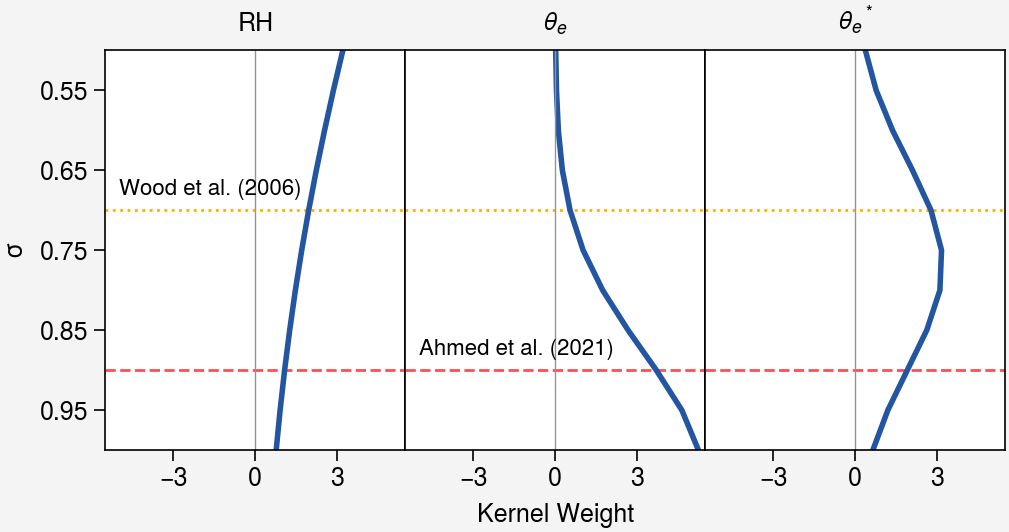

5.13


In [5]:
fig,axs = pplt.subplots(ncols=len(FIELDVARS),refwidth=1.5,refheight=2,share=True,space=0)
axs.format(grid=False,collabels=[VARLABELS[var] for var in FIELDVARS],xlabel='Kernel Weight',
           ylabel=r'$\sigma$',ylim=(1,0.5),yticks=[0.95,0.85,0.75,0.65,0.55])
for col in range(len(FIELDVARS)):
    ax = axs[col]
    if col!=0:
        ax.tick_params(axis='y',left=False,labelleft=False)
    ax.axvline(0,color='gray',linewidth=0.5)
    ax.axhline(0.7,color='yellow6',linewidth=1,linestyle=':',zorder=0)
    ax.axhline(0.9,color='red6',linewidth=1,linestyle='--',zorder=0)
    ax.plot(kernels['nn_gauss'][1][col],sig,color='#2355A1',linewidth=2,zorder=1)
    ax.format(xlim=(-5.5,5.5),xticks=3)
axs[1].text(-5.0,0.86,'Ahmed et al. (2021)',va='top',ha='left',fontsize=8)
axs[0].text(-5.0,0.66,'Wood et al. (2006)',va='top',ha='left',fontsize=8)
pplt.show()
fig.save(os.path.join(FIGSDIR,'fig_3.jpg'))
print(round(fig.get_figwidth(),2))

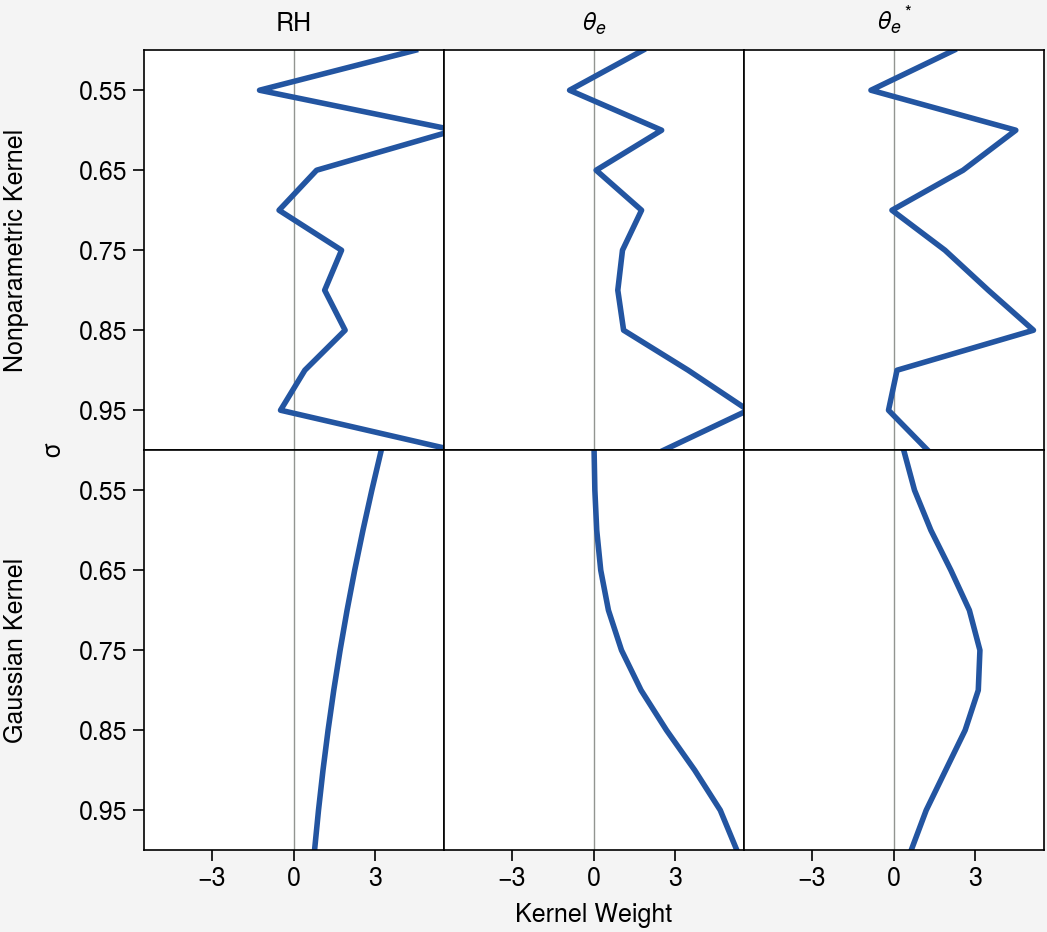

5.32


In [6]:
panels  = [(name,*kernel[1:]) for name,kernel in kernels.items() if 'rot' not in name]
fig,axs = pplt.subplots(nrows=len(panels),ncols=len(FIELDVARS),refwidth=1.5,refheight=2,share=True,space=0)
axs.format(grid=False,rowlabels=['Nonparametric Kernel','Gaussian Kernel'],collabels=[VARLABELS[var] for var in FIELDVARS],xlabel='Kernel Weight',
           ylabel='$\\sigma$',ylim=(1,0.5),yticks=[0.95,0.85,0.75,0.65,0.55])
for row,(name,kmean,kstd) in enumerate(panels):
    for col in range(len(FIELDVARS)):
        ax = axs[row,col]
        if row!=len(panels)-1:
            ax.tick_params(axis='x',bottom=False,labelbottom=False)
        if col!=0:
            ax.tick_params(axis='y',left=False,labelleft=False)
        ax.axvline(0,color='gray',linewidth=0.5)
        ax.plot(kmean[col],sig,color='#2355A1',linewidth=2)
        ax.format(xlim=(-5.5,5.5),xticks=3)
pplt.show()
fig.save(os.path.join(FIGSDIR,'fig_S1.jpg'))
print(round(fig.get_figwidth(),2))

In [7]:
dsig = np.abs(np.gradient(sig))
rows = []
for name,(fieldvars,kmean,_) in kernels.items():
    if 'nonparam' in name:
        continue
    for i,var in enumerate(fieldvars):
        center = float(sig[np.argmax(kmean[i])])
        rows.append({'Predictor':VARLABELS.get(var,var),r'$\sigma_c$':center,r'$\sigma_w$':float(np.sqrt(((sig-center)**2*kmean[i]*dsig).sum()))})
display(pd.DataFrame(rows).style.format({r'$\sigma_c$':'{:.2f}',r'$\sigma_w$':'{:.3f}'}).hide(axis='index'))

Predictor,$\sigma_c$,$\sigma_w$
RH,0.50,0.235
$\mathit{\theta_{e}}$,1.00,0.133
$\mathit{\theta_{e}}^*$,0.75,0.118


In [8]:
mapping = fit_qm(*load_pairs(SPLITSDIR,FITSPLITS),nquantiles=NQUANTILES)
with xr.open_dataset(os.path.join(SPLITSDIR,'valid.h5'),engine='h5netcdf') as ds:
    truetp = ds['pr'].transpose('time','lat','lon').load()
writer = PredictionWriter(SPLITSDIR,targetvar=TARGETVAR)
rows   = []
for name in ['nn_gauss','nn_nonparam']:
    run = NNRUNS[name]
    fields,local,pr,dsig,nlevs,valid,refda = load_split('valid',run['fieldvars'],run.get('localvars',[]),SPLITSDIR,targetvar=TARGETVAR,subset=run.get('subset'))
    dataloader = torch.utils.data.DataLoader(FieldDataset(fields,local,pr,dsig),batch_size=BATCHSIZE,shuffle=False,num_workers=0)
    scores = []
    for seed in SEEDS:
        model = load(name,run,nlevs,MODELSDIR,seed,DEVICE)
        if model is None:
            continue
        preds,_ = Inferencer(model,dataloader,DEVICE).predict(True)
        predtp  = apply_qm(mapping,writer.predictions_to_dataset([preds],valid,refda)[TARGETVAR].isel(seed=0))
        seedtrue,seedpred = xr.align(truetp,predtp,join='inner')
        mask = np.isfinite(seedtrue.values)&np.isfinite(seedpred.values)
        ytrue,ypred = seedtrue.values[mask],seedpred.values[mask]
        scores.append(1-np.sum((ypred-ytrue)**2)/np.sum((ytrue-ytrue.mean())**2))
        del model
    rows.append({'Model':run['description'],r'$\mathrm{R}^2$':np.mean(scores)})

In [9]:
display(pd.DataFrame(rows).style.format({r'$\mathrm{R}^2$':'{:.3f}'}).hide(axis='index'))

Model,$\mathrm{R}^2$
NN-GAUSS,-0.052
NN-NONPARAM,-0.047
